# **1. 오토인코더**
오토인코더(Autoencoder)는 입력 데이터를 효율적으로 압축하고 다시 복원하는 것을 목표로 하는 인공신경망 기반의 비지도 학습 모델입니다. 인코더(encoder)라는 신경망 구조를 통해 입력 데이터를 저차원(latent space)의 잠재 표현으로 변환하고, 디코더(decoder)를 통해 이를 다시 원래의 입력 데이터로 복원합니다. 학습은 원본 입력과 복원된 출력 간의 재구성 오류(reconstruction error)를 최소화하는 방식으로 이루어지며, 이를 통해 데이터의 핵심 특징을 추출하거나 노이즈 제거, 차원 축소 등에 활용됩니다. 오토인코더는 생성 모델의 기초가 되는 구조로서, 이후 변분 오토인코더(VAE)나 GAN과 같은 발전된 모델에도 큰 영향을 주었습니다.

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FzmRnT%2FbtsPKmlE2Yx%2FAAAAAAAAAAAAAAAAAAAAAFBXyN-ciM0RoMyxJ7QeQumtfm0tJYth-uWz6ZXp1q8i%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1772290799%26allow_ip%3D%26allow_referer%3D%26signature%3DLCV1RdzvqNvLAIOF3txH3lYD%252B3U%253D'>

### 1. 인코더 (Encoder): 데이터를 요약하는 압축기
인코더는 고차원 데이터를 받아서, 그 핵심적인 특징만을 담은 저차원 잠재 표현(latent vector)으로 바꿔줍니다.

1. 입력 이미지가 28x28 픽셀이라면, 총 784개의 숫자가 들어옵니다.
2. 인코더는 이 784개의 숫자 중에서 정말 중요한 특징만 뽑아내서, 예를 들어 32차원 벡터로 요약합니다. 이걸 보통 잠재 공간(latent space)이라고 부릅니다.

##2. 디코더 (Decoder): 요약 정보를 복원하는 재생기
디코더는 인코더가 만든 요약 정보를 보고, 최대한 원래 데이터와 비슷하게 복원하려고 합니다.

1. 인코더가 만든 32차원의 벡터를 받아서,
2. 다시 784개의 숫자 (28x28 이미지)로 복원하려고 합니다.
3. 이 때, 인코더에서 잃은 정보를 복원하기 때문에, 완전히 같진 않을 수 있지만 비슷하게 재현하려고 합니다.

# **2. 오토인코더 구현하기**
노이즈 없이 단순히 입력 이미지를 자기 자신으로 복원하는 기본 오토인코더 구조

In [1]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(X_train, _), (X_test, _) = mnist.load_data()

# (샘플수, 28, 28) -> (28, 28, 1) -> (샘플수, 28, 28, 1)
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
autoencoder = Sequential()
# 28 * 28 * 16
autoencoder.add(Conv2D(16, kernel_size=3, padding='same', activation='relu', input_shape=(28, 28, 1)))
# 14 * 14 * 16
autoencoder.add(MaxPooling2D(pool_size=2, padding='same'))
# 14 * 14 * 8
autoencoder.add(Conv2D(8, kernel_size=3, padding='same', activation='relu'))
# 7 * 7 * 8
autoencoder.add(MaxPooling2D(pool_size=2, padding='same'))
# 7 * 7 * 8
autoencoder.add(Conv2D(8, kernel_size=3, padding='same', activation='relu'))

# 14 * 14 * 8
autoencoder.add(UpSampling2D())
# 14 * 14 * 16
autoencoder.add(Conv2D(16, kernel_size=3, padding='same', activation='relu'))
# 28 * 28 * 16
autoencoder.add(UpSampling2D())
# 28 * 28 * 1
# 흑백 이미지로 복원
# 시그모이드를 사용하는 이유는 출력 픽셀 값을 0 ~ 1 범위로 만들기 위함(정규화된 입력값과 동일)
autoencoder.add(Conv2D(1, kernel_size=3, padding='same', activation='sigmoid'))
autoencoder.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,217 (12.57 KB)

 Trainable params: 3,217 (12.57 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
history = autoencoder.fit(X_train, X_train, epochs=50, batch_size=128,
                          validation_data=(X_test, X_test), verbose=1)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 62s 124ms/step - loss: 0.2934 - val_loss: 0.0901
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 58s 123ms/step - loss: 0.0889 - val_loss: 0.0832
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 120ms/step - loss: 0.0829 - val_loss: 0.0798
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 121ms/step - loss: 0.0801 - val_loss: 0.0781
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 118ms/step - loss: 0.0785 - val_loss: 0.0768
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 120ms/step - loss: 0.0773 - val_loss: 0.0759
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 56s 119ms/step - loss: 0.0763 - val_loss: 0.0750
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 56s 120ms/step - loss: 0.0754 - val_loss: 0.0743
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 55s 118ms/step - loss: 0.0749 - val_loss: 0.0738
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 125ms/step - loss: 0.0743 - val_loss: 0.0734
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 78s 117ms/step - loss: 0.0741 - val_loss: 0.0730
Epoch 12/50
469/469

In [ ]:
random_idx = np.random.randint(X_test.shape[0], size=5)
recons = autoencoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


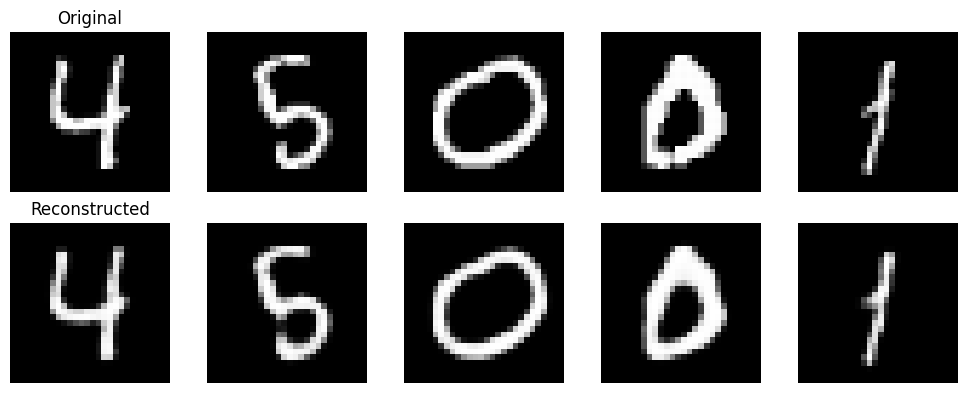

In [ ]:
plt.figure(figsize=(10, 4))

for i, idx in enumerate(random_idx):
    ax = plt.subplot(2, 5, i+1)
    plt.imshow(X_test[idx].squeeze(), cmap='gray')
    ax.axis('off')
    if i == 0:
        ax.set_title('Original')
    ax = plt.subplot(2, 5, 5 + i + 1)
    plt.imshow(recons[idx].squeeze(), cmap='gray')
    ax.axis('off')
    if i == 0:
        ax.set_title('Reconstructed')
plt.tight_layout()
plt.show()

# **3. Sparse Autoencoder**
Sparse Autoencoder는 입력 데이터를 압축된 형태로 표현하는 오토인코더의 한 종류로, 잠재 공간(latent space)에서 대부분의 뉴런이 0에 가깝고 일부만 활성화되도록 강제하는 구조입니다. 이렇게 희소성을 주기 위해 L1 정규화나 KL Divergence 기반의 제약을 추가하여, 모델이 단순히 모든 뉴런을 다 쓰는 대신 중요한 특징만 선택적으로 사용하도록 유도합니다. 그 결과, Sparse Autoencoder는 데이터의 핵심적인 특징을 더 해석 가능하고 압축된 방식으로 표현할 수 있으며, 차원 축소, 특징 추출, 이상 탐지 등 다양한 분야에서 활용됩니다.

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2Fcjjxpw%2FbtsPWe2WGbx%2FAAAAAAAAAAAAAAAAAAAAALyMjC49V6hjljp1KbnRDWKYAHsyaL1qxhbQRy-xrwSw%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1772290799%26allow_ip%3D%26allow_referer%3D%26signature%3D2RanxBswP%252BTtKrI3eiSmas%252BrC7Q%253D'>

# **4. Denoising Autoencoder**
Denoising Autoencoder는 입력 데이터에 일부러 노이즈를 추가한 뒤, 그 손상된 데이터를 원래의 깨끗한 데이터로 복원하도록 학습하는 오토인코더입니다. 이렇게 학습하면 모델은 단순히 입력을 복사하는 대신 데이터의 본질적 패턴과 구조를 더 잘 학습하게 되며, 잡음에 강인한 표현을 얻을 수 있습니다. 그 결과, Denoising Autoencoder는 특징 추출, 데이터 전처리, 이상 탐지 등에서 활용되며, 노이즈 제거뿐 아니라 일반적인 강건한 표현 학습(robust representation learning) 방법으로 널리 사용됩니다.

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FEdMFB%2FbtsPW3mcfGr%2FAAAAAAAAAAAAAAAAAAAAAGj8rQc0AzZ1agMVhJrVeP0_tGhhcYFZmCuc-vlzI1vj%2Fimg.webp%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1772290799%26allow_ip%3D%26allow_referer%3D%26signature%3DvsiWaMI%252BrEE967Uf98ns6ACABDc%253D'>

In [ ]:
import torch.nn as nn

In [ ]:
class Encoder(nn.Module):
    def __init__(self, num_input_channels, base_channel_size, latent_dim):
        super().__init__()
        # [B, C, H, W]
        self.net = nn.Sequential(
            nn.Conv2d(num_input_channels, base_channel_size, kernel_size=3, padding=1, stride=2),
            nn.GELU(),
            nn.Conv2d(base_channel_size, base_channel_size, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(base_channel_size, 2*base_channel_size, kernel_size=3, padding=1, stride=2),
            nn.GELU(),
            nn.Conv2d(2*base_channel_size, 2*base_channel_size, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(2*base_channel_size, 2*base_channel_size, kernel_size=3, padding=1, stride=2),
            nn.GELU(),
            nn.Flatten(),
            nn.Linear(2*16*base_channel_size, latent_dim)
        )

    def forward(self, x):
        return self.net(x)

### GELU를 사용하는 이유
- 부드러움(Smoothness): 0 부근에서 미분이 연속이라 기울기 소실/폭주 완화에 유리하고, 학습이 안정적입니다. (ReLU는 0에서 미분이 뚝 끊깁니다.)
- 정보 보존: 작은 음수도 조금은 통과시켜서, ReLU처럼 음수 영역 뉴런이 “죽어버리는(dead)” 현상을 줄입니다.
- 경험적 성능: NLP의 Transformer(BERT, GPT 계열), 비전의 최신 아키텍처에서 GELU가 ReLU보다 성능이 더 좋은 경우가 자주 보고되었습니다. CNN에도 무난히 잘 맞습니다.

In [ ]:
class Decoder(nn.Module):
    def __init__(self, num_input_channels, base_channel_size, latent_dim):
        super().__init__()
        self.linear = nn.Sequential(
            nn.Linear(latent_dim, 2*16*base_channel_size),
            nn.GELU()
        )
        self.net = nn.Sequential(
            nn.ConvTranspose2d(
                # output_padding: ConvTranspose2d 출력 크기가 1칸 또는 여러칸의 사이즈가 맞지 않을 수 있음. 출력 크기를 맞추기 위한 보정 값
                2*base_channel_size, 2*base_channel_size, kernel_size=3, output_padding=1, padding=1, stride=2
            ),
            nn.GELU(),
            nn.Conv2d(2*base_channel_size, 2*base_channel_size, kernel_size=3, padding=1),
            nn.GELU(),
            nn.ConvTranspose2d(
                2*base_channel_size, base_channel_size, kernel_size=3, output_padding=1, padding=1, stride=2
            ),
            nn.GELU(),
            nn.Conv2d(base_channel_size, base_channel_size, kernel_size=3, padding=1),
            nn.GELU(),
            nn.ConvTranspose2d(
                base_channel_size, num_input_channels, kernel_size=3, output_padding=1, padding=1, stride=2
            ),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.linear(x)
        # print(x.shape)
        x = x.reshape(x.shape[0], -1, 4, 4)
        x = self.net(x)
        return x

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, num_input_channels, base_channel_size, latent_dim):
        super().__init__()
        self.encoder = Encoder(num_input_channels, base_channel_size, latent_dim)
        self.decoder = Decoder(num_input_channels, base_channel_size, latent_dim)

    def forward(self, x):
        latent = self.encoder(x)
        output = self.decoder(latent)
        return latent, output

In [ ]:
model = Autoencoder(num_input_channels=3, base_channel_size=64, latent_dim=256)
model

Autoencoder(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): GELU(approximate='none')
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): GELU(approximate='none')
      (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (5): GELU(approximate='none')
      (6): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): GELU(approximate='none')
      (8): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (9): GELU(approximate='none')
      (10): Flatten(start_dim=1, end_dim=-1)
      (11): Linear(in_features=2048, out_features=256, bias=True)
    )
  )
  (decoder): Decoder(
    (linear): Sequential(
      (0): Linear(in_features=256, out_features=2048, bias=True)
      (1): GELU(approximate='none')
    )
    (net): Sequential(
      (0): ConvTranspose2d(128, 128, kernel_size=(3, 3), stride=(2, 2), pa

In [ ]:
import torch
from torchvision.transforms import v2

In [ ]:
trn_transforms = v2.Compose([
    # 모든 이미지 타입을 텐서형으로 표준화
    v2.ToImage(),
    # 이미지를 임의의 위치/임의의 크기로 잘라낸 뒤 결과를 32*32로 리사이즈
    v2.RandomResizedCrop(size=(32, 32), antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    # dtype을 float32로 바꿈. 정수 픽셀을 자동으로 0 ~ 1로 스케일링
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

test_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize(size=(32, 32), antialias=True),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [ ]:
from torchvision.datasets import CIFAR10

In [ ]:
trn_dataset = CIFAR10(".", train=True, download=True, transform=trn_transforms)
test_dataset = CIFAR10(".", train=False, download=True, transform=test_transforms)

100%|██████████| 170M/170M [00:02<00:00, 72.3MB/s]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision.utils as vutils

In [ ]:
def imshow(inputs, title):
    mean = 0.5
    std = 0.5
    inputs = std * inputs + mean
    inputs = torch.clip(inputs, 0, 1)
    grid = vutils.make_grid(inputs, padding=2, normalize=True)

    plt.figure(figsize=(8, 8))
    plt.axis('off')
    plt.title(title)
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.show()
    plt.close()

In [ ]:
trn_loader = torch.utils.data.DataLoader(trn_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [ ]:
from tqdm import tqdm

In [ ]:
def train(model, criterion, optimizer, trn_loader, test_loader, device, num_epochs):
    for epoch in range(num_epochs):
        model.train()
        trn_loss = 0.0
        for inputs, _ in tqdm(trn_loader):
            inputs = inputs.to(device)
            _, outputs = model(inputs)
            loss = criterion(outputs, inputs)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            trn_loss += loss.item() * inputs.size(0)
        trn_epoch_loss = trn_loss / len(trn_loader.dataset)
        print(f'[Train] Loss: {trn_epoch_loss:.4f}')

        with torch.no_grad():
            model.eval()
            test_loss = 0.0
            for inputs, _ in tqdm(test_loader):
                inputs = inputs.to(device)
                _, outputs = model(inputs)
                loss = criterion(outputs, inputs)
                test_loss += loss.item() * inputs.size(0)
            test_epoch_loss = test_loss / len(test_loader.dataset)
            print(f'[Test] Loss: {test_epoch_loss:.4f}')
            imshow(inputs.cpu(), 'Inputs')
            imshow(outputs.cpu(), 'outputs')

In [ ]:
import torch.optim as optim

In [ ]:
model = model.to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
train(model, criterion, optimizer, trn_loader, test_loader, device, num_epochs=10)